# Epilepsy: 4-class clustering of motion-sensor recordings

UEA Epilepsy benchmark (Villar et al. 2016). 275 records of length 206, three-channel wrist accelerometer (x, y, z), four balanced classes: EPILEPSY (seizure motion), RUNNING, WALKING, SAWING.

Classes differ along two essentially independent axes: rhythm (the dominant motion frequency) and intensity (per-channel signal energy).

`filt_freq` is L2 on the channel-concatenated FFT magnitude after per-record z-normalisation.

`filt_energy` is L2 on the 3-d per-channel sqrt(sum x^2).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from tslearn.datasets import UCR_UEA_datasets

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges
from mpc.experiment_utils import align_hungarian

## Data

full set: N=275 L=206 C=3 classes=['EPILEPSY', 'RUNNING', 'SAWING', 'WALKING']
subsample: N=200 L=206 C=3, train=140 test=60
class counts (test): [15 15 15 15]


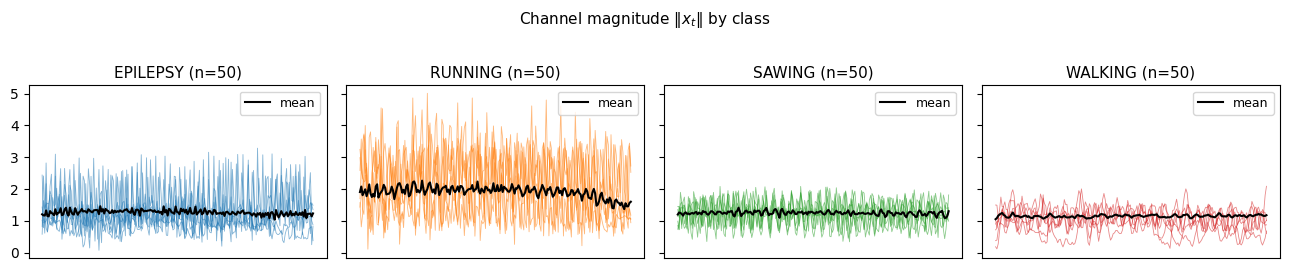

In [ ]:
X_tr, y_tr, X_te, y_te = UCR_UEA_datasets().load_dataset('Epilepsy')
X_full = np.vstack([X_tr, X_te])
y_str = np.concatenate([y_tr, y_te])
CLASSES, y_full = np.unique(y_str, return_inverse=True)
print(f'full set: N={len(X_full)} L={X_full.shape[1]} C={X_full.shape[2]} classes={CLASSES.tolist()}')

K_TRUE = len(CLASSES)
PER_CLASS = 50
rng = np.random.default_rng(42)
sel = []
for c in range(K_TRUE):
    idx_c = np.where(y_full == c)[0]
    sel.extend(rng.choice(idx_c, PER_CLASS, replace=False))
sel = np.array(sel); rng.shuffle(sel)
X = X_full[sel]; y_true = y_full[sel]
N, L, C = X.shape

all_idx = np.arange(N)
train_idx, test_idx = train_test_split(all_idx, test_size=0.30,
                                       stratify=y_true, random_state=42)
train_idx.sort()
test_idx.sort()
y_train = y_true[train_idx]; y_test = y_true[test_idx]
print(f'subsample: N={N} L={L} C={C}, train={len(train_idx)} test={len(test_idx)}')
print(f'class counts (test): {np.bincount(y_test)}')

CLASS_COLORS = ['C0', 'C1', 'C2', 'C3']
fig, axes = plt.subplots(1, K_TRUE, figsize=(13, 2.6), sharey=True)
for ax, c in zip(axes, range(K_TRUE)):
    mag_c = np.linalg.norm(X[y_true == c], axis=2)
    for m in mag_c[:6]:
        ax.plot(m, color=CLASS_COLORS[c], lw=0.6, alpha=0.55)
    ax.plot(mag_c.mean(0), color='k', lw=1.5, label='mean')
    ax.set_title(f'{CLASSES[c]} (n={(y_true == c).sum()})', fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=9)
fig.suptitle('Channel magnitude $\\|x_t\\|$ by class', y=1.02, fontsize=11)
fig.tight_layout()
plt.show()

## Filtrations

The main pair is `freq x energy`.

`freq`, L2 on channel-concatenated FFT magnitude after per-record z-norm.

`energy`, L2 on 3-d per-channel signal energy sqrt(sum x^2).

other pairs can be:

`raw`, L2 on raw 618-d (3-channel concat).

`deriv`, L2 on first-difference 3-channel concat.

`ampch`, L2 on 3-d per-channel peak-to-peak.

`peakloc`, L2 on 3-d per-channel argmax positions.

In [3]:
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)
spec_z = np.abs(np.fft.rfft(Xz, axis=1)).reshape(N, -1)
energy_pc = np.sqrt((X ** 2).sum(axis=1))
raw_flat = X.reshape(N, -1)
deriv_flat = np.diff(X, axis=1).reshape(N, -1)
ampch = X.max(1) - X.min(1)
peakloc = np.argmax(X, axis=1).astype(float)

D_axes = {
    'freq': cdist(spec_z, spec_z),
    'energy': cdist(energy_pc, energy_pc),
    'raw': cdist(raw_flat, raw_flat),
    'deriv': cdist(deriv_flat, deriv_flat),
    'ampch': cdist(ampch, ampch),
    'peakloc': cdist(peakloc, peakloc),
}
iu, ju = np.triu_indices(N, k=1)
edges = list(zip(iu.tolist(), ju.tolist()))
F_axes = {k: assemble_filtration(N, edges, v[iu, ju]) for k, v in D_axes.items()}

filt_freq, filt_energy = F_axes['freq'], F_axes['energy']

## Tuning

Bifiltration

GMM on the engineered 2D features `(dom_freq_mean, total_energy)`

GMM with diagonal covariance on the raw 618-d 3-channel concatenation

KMeans on the same raw 618-d.

In [4]:
def tune_and_eval(name, configs):
    best_train, best_pred, best_label = -1.0, None, None
    for label, labels in configs:
        labels = np.asarray(labels)
        a = adjusted_rand_score(y_train, labels[train_idx])
        if a > best_train:
            best_train, best_pred, best_label = a, labels, label
    test_ari = adjusted_rand_score(y_test, best_pred[test_idx])
    test_nmi = normalized_mutual_info_score(y_test, best_pred[test_idx])
    return {'method': name, 'best_config': best_label,
            'train_ARI': best_train, 'test_ARI': test_ari,
            'test_NMI': test_nmi, 'pred': best_pred}

def bif_configs(methods):
    cfgs = []
    for slope in [0.0625, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
        for k in [2, 3, 4, 5, 6]:
            for meth in methods:
                if meth == 'simplify':
                    for ms in [2, 3, 5, 8, 12, 20]:
                        r = run_bifiltration_edges(N, filt_freq, filt_energy, method=meth,
                                                   n_clusters=k, slope=slope, min_size=ms)
                        cfgs.append((f'{meth} slope={slope} k={k} ms={ms}', r.labels_combined))
                else:
                    r = run_bifiltration_edges(N, filt_freq, filt_energy, method=meth,
                                               n_clusters=k, slope=slope)
                    cfgs.append((f'{meth} slope={slope} k={k}', r.labels_combined))
    return cfgs

dom_freq_mean = np.argmax(np.abs(np.fft.rfft(Xz, axis=1)), axis=1).mean(axis=1)
total_energy = energy_pc.sum(axis=1)
feat = StandardScaler().fit_transform(np.column_stack([dom_freq_mean, total_energy]))
feat_raw = raw_flat

gmm_cfgs = [(f'{cov} k={k}',
             GaussianMixture(n_components=k, covariance_type=cov, n_init=20,
                             max_iter=500, reg_covar=1e-4,
                             random_state=42).fit_predict(feat))
            for cov in ('full', 'tied', 'diag') for k in [2, 3, 4, 5]]
gmm_raw_cfgs = [(f'raw618 diag k={k}',
                 GaussianMixture(n_components=k, covariance_type='diag', n_init=20,
                                 max_iter=500, reg_covar=1e-4,
                                 random_state=42).fit_predict(feat_raw))
                for k in [2, 3, 4, 5, 6]]
km_raw_cfgs = [(f'raw618 k={k}',
                KMeans(n_clusters=k, n_init=50, max_iter=500,
                       random_state=42).fit_predict(feat_raw))
               for k in [2, 3, 4, 5, 6]]

results = [
    tune_and_eval('Bifiltration (persist)', bif_configs(('persistence',))),
    tune_and_eval('GMM 2D', gmm_cfgs),
    tune_and_eval('GMM',    gmm_raw_cfgs),
    tune_and_eval('KMeans', km_raw_cfgs),
]
df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pred'} for r in results])
df.sort_values('test_ARI', ascending=False).reset_index(drop=True).round(3)

,method,best_config,train_ARI,test_ARI,test_NMI
0,Bifiltration (persist),persistence slope=0.125 k=5,0.783,0.677,0.737
1,GMM 2D,diag k=3,0.562,0.469,0.548
2,GMM,raw618 diag k=6,0.268,0.244,0.408
3,KMeans,raw618 k=6,0.147,0.211,0.368


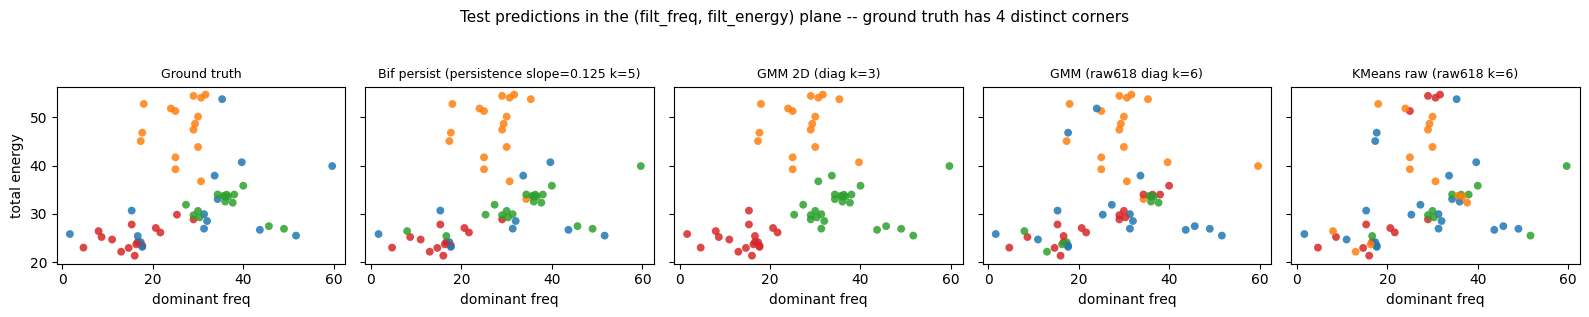

In [ ]:
res_by_name = {r['method']: r for r in results}

PRED_COLORS = ['C0', 'C1', 'C2', 'C3']

methods_to_show = [
    ('Ground truth', y_true),
    (f"Bif persist ({res_by_name['Bifiltration (persist)']['best_config']})",
     res_by_name['Bifiltration (persist)']['pred']),
    (f"GMM 2D ({res_by_name['GMM 2D']['best_config']})",
     res_by_name['GMM 2D']['pred']),
    (f"GMM ({res_by_name['GMM']['best_config']})",
     res_by_name['GMM']['pred']),
    (f"KMeans raw ({res_by_name['KMeans']['best_config']})",
     res_by_name['KMeans']['pred']),
]

fig, axes = plt.subplots(1, len(methods_to_show), figsize=(16, 3.0),
                         sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, methods_to_show):
    aligned, _ = align_hungarian(np.asarray(labels), y_true)
    colors = [PRED_COLORS[(int(a) - 1) % K_TRUE] for a in aligned[test_idx]]
    ax.scatter(dom_freq_mean[test_idx], total_energy[test_idx],
               c=colors, s=32, alpha=0.85, edgecolors='none')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('dominant freq')
axes[0].set_ylabel('total energy')
fig.suptitle('Test predictions in the (filt_freq, filt_energy) plane '
             '-- ground truth has 4 distinct corners',
             y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

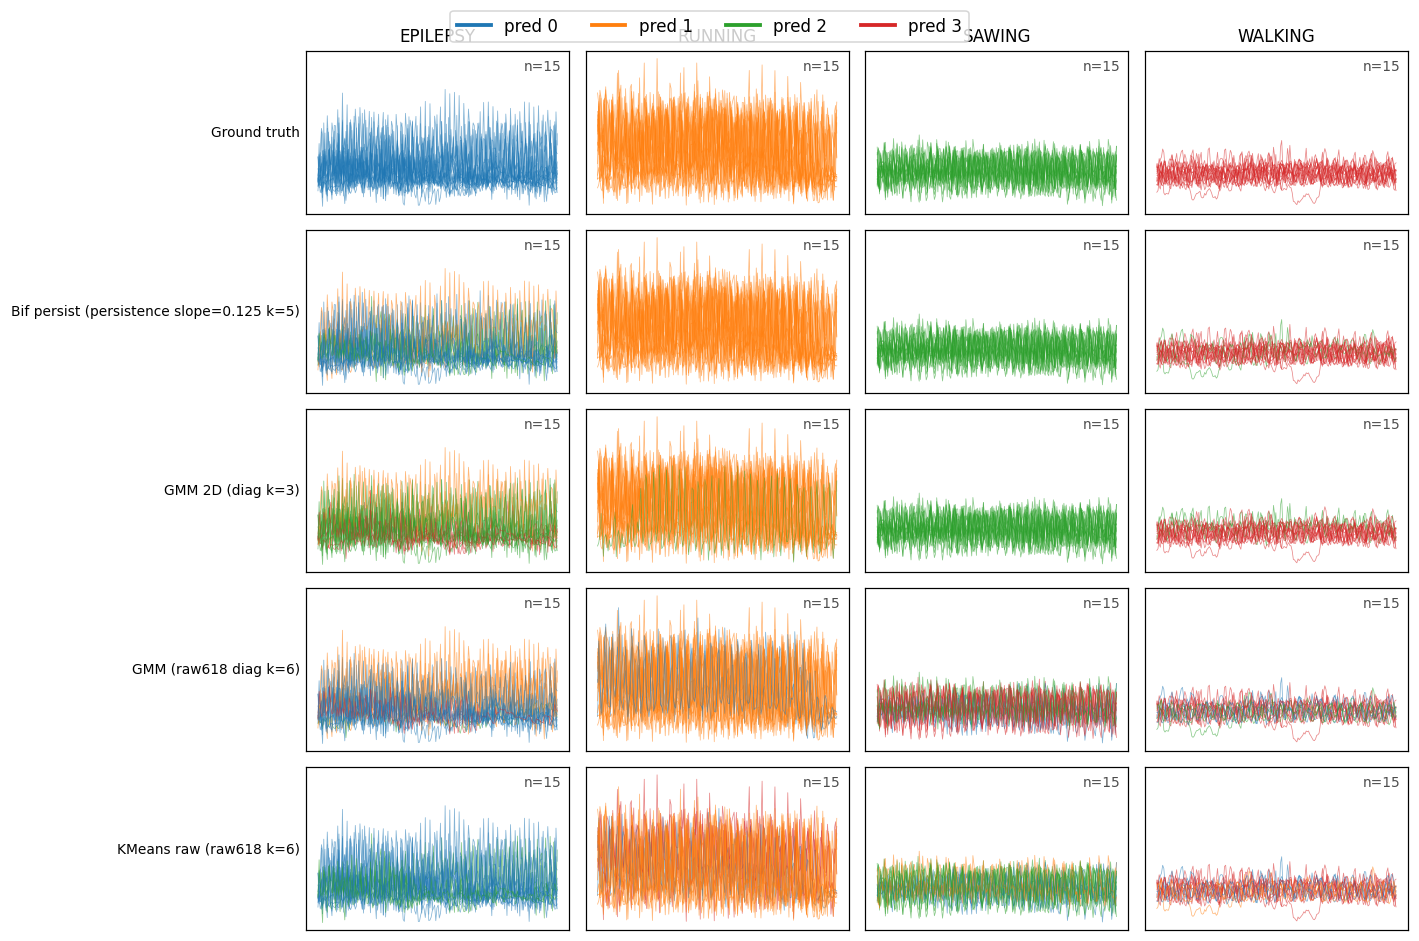

In [ ]:
X_mag = np.linalg.norm(X, axis=2)

fig, axes = plt.subplots(len(methods_to_show), K_TRUE,
                         figsize=(13, 1.7 * len(methods_to_show)),
                         sharex=True, sharey=True, dpi=110)
for row, (name, labels) in enumerate(methods_to_show):
    aligned, _ = align_hungarian(np.asarray(labels), y_true)
    for col in range(K_TRUE):
        ax = axes[row, col]
        idxs = test_idx[y_true[test_idx] == col]
        for i in idxs:
            ax.plot(X_mag[i], color=PRED_COLORS[(aligned[i] - 1) % K_TRUE], lw=0.5, alpha=0.55)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.97, 0.95, f'n={len(idxs)}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='0.3')
        if row == 0:
            ax.set_title(f'{CLASSES[col]}', fontsize=11)
        if col == 0:
            ax.set_ylabel(name, fontsize=9, rotation=0, ha='right', va='center')

handles = [plt.Line2D([0], [0], color=PRED_COLORS[c], lw=2.5, label=f'pred {c}')
           for c in range(K_TRUE)]
fig.legend(handles=handles, loc='upper center', ncol=K_TRUE,
           bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.tight_layout()
plt.show()